In [1]:
import os, gc
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
# import squidpy as sq
import h5py
import math
from tqdm import tqdm
import scipy.sparse as sps
import scipy.io as sio
import seaborn as sns
import warnings

from os.path import join
import torch

import logging
import torch
from matplotlib import rcParams
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# import sys
# sys.path.insert(0, '../../..')

import utils as utls 
from loss import CL_loss
from preprocessing import RNA_preprocess, ADT_preprocess, Epigenome_preprocess, harmony

os.environ['R_HOME'] = '/home/yanxh/anaconda3/envs/R4.3/lib/R'
os.environ['R_USER'] = '/home/yanxh/anaconda3/envs/R4.3/lib/python3.8/site-packages/rpy2'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' 

In [2]:
import random
def set_seeds(seed, dt=True):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.benchmark = True
    torch.use_deterministic_algorithms(dt)  # ensure reproducibility

In [3]:
class Encoder(nn.Module):
    def __init__(
        self,
        n_input,
        embedding_size,
        dropout_rates,
        dims_layers,
    ):
        super(Encoder, self).__init__()
        dropout = []
        layers = [nn.Linear(n_input, dims_layers[0])]

        for i in range(len(dims_layers) - 1):
            layers.append(nn.Linear(dims_layers[i], dims_layers[i + 1]))
        for i in range(len(dropout_rates)):
            dropout.append(nn.Dropout(p=dropout_rates[i]))

        layers.append(nn.Linear(dims_layers[-1], embedding_size))

        self.fc_list = nn.ModuleList(layers)
        # print("dropout list", dropout)
        self.dropout_list = nn.ModuleList(dropout)
        self.decoder = nn.Linear(embedding_size, n_input)

    def forward(self, x):
        for i in range(len(self.fc_list) - 1):
            x = F.elu(self.fc_list[i](x))
            if i < len(self.dropout_list):
                x = self.dropout_list[i](x)

        x = self.fc_list[-1](x)
        r = self.decoder(x)
        
        x = F.normalize(x, dim=1, p=2)
        return x, r

def step_stage1_training(
    model1, model2,
    bridge_feat1, bridge_feat2,
    indiv_feat1, indiv_feat2,
    optim1, optim2,
    crit1, crit2,
    T,
    n_epochs,
    device,
    batch_size,
    recon_weight=1.0
):
    n_bridge_samples = bridge_feat1.shape[0]
    n_indiv1_samples = indiv_feat1.shape[0] if indiv_feat1 is not None else 0
    n_indiv2_samples = indiv_feat2.shape[0] if indiv_feat2 is not None else 0

    loss_cl_list, loss_rec_list = [], []

    for epoch in tqdm(range(1, n_epochs + 1)):
        bridge_idx = torch.randperm(n_bridge_samples)
        indiv1_idx = torch.randperm(n_indiv1_samples) if n_indiv1_samples > 0 else None
        indiv2_idx = torch.randperm(n_indiv2_samples) if n_indiv2_samples > 0 else None

        epoch_loss_cl, epoch_loss_rec = 0.0, 0.0

        optim1.zero_grad()
        optim2.zero_grad()

        total_loss_cl = 0.0
        total_loss_rec = 0.0

        for start in range(0, n_bridge_samples//batch_size*batch_size, batch_size):
            end = start + batch_size
            batch_idx = bridge_idx[start:end]
            batch_bridge_feat1 = bridge_feat1[batch_idx].to(device)
            batch_bridge_feat2 = bridge_feat2[batch_idx].to(device)

            z1, _ = model1(batch_bridge_feat1)
            z2, _ = model2(batch_bridge_feat2)

            feat = torch.cat([z1, z2])
            # IIDS = torch.arange(feat.shape[0]).repeat(2).to(device)
            loss_cl = crit1((feat @ feat.T) / T)

            total_loss_cl = total_loss_cl + loss_cl
            epoch_loss_cl += loss_cl.item()

        if n_indiv1_samples > 0:
            for start in range(0, n_indiv1_samples, batch_size):
                end = start + batch_size
                batch_idx = indiv1_idx[start:end]
                batch_indiv_feat1 = indiv_feat1[batch_idx].to(device)

                _, recon_indiv1 = model1(batch_indiv_feat1)
                loss_rec1 = crit2(recon_indiv1, batch_indiv_feat1)

                total_loss_rec = total_loss_rec + loss_rec1
                epoch_loss_rec += loss_rec1.item()

        # ---- indiv_feat2 reconstruction loss ----
        if n_indiv2_samples > 0:
            for start in range(0, n_indiv2_samples, batch_size):
                end = start + batch_size
                batch_idx = indiv2_idx[start:end]
                batch_indiv_feat2 = indiv_feat2[batch_idx].to(device)

                _, recon_indiv2 = model2(batch_indiv_feat2)
                loss_rec2 = crit2(recon_indiv2, batch_indiv_feat2)

                total_loss_rec = total_loss_rec + loss_rec2
                epoch_loss_rec += loss_rec2.item()

        # ---- 所有 loss 累加后统一 backward + step ----
        total_loss = total_loss_cl + recon_weight * total_loss_rec
        total_loss.backward()

        optim1.step()
        optim2.step()

        optim1.zero_grad()
        optim2.zero_grad()

        loss_cl_list.append(epoch_loss_cl)
        loss_rec_list.append(epoch_loss_rec)

    return model1, model2, loss_cl_list, loss_rec_list

from torch.utils.data import Dataset
import torch.utils.data.dataloader as dataloader
class BaseDataset(Dataset):
    def __init__(self, feats):
        if torch.is_tensor(feats):
            feats = feats.detach().cpu().numpy()
        elif sps.issparse(feats):
            feats = feats.A  # 转成 ndarray
        else:
            feats = np.asarray(feats)
        
        self.X = feats.astype(np.float32)
        self.sample_num = self.X.shape[0]
        self.input_size = self.X.shape[1]

    def __len__(self):
        return self.sample_num

    def __getitem__(self, i):
        return self.X[i]

def model_inference(model, feat, device):
    model.eval()
    ds = BaseDataset(feat)
    dl = dataloader.DataLoader(ds, batch_size=256, shuffle=False, num_workers=1, drop_last=False)

    out = []
    with torch.no_grad():
        for batch in dl:
            batch = batch.to(device)
            z, _ = model(batch)
            out.append(z.cpu().numpy())
    out = np.vstack(out)
    return out
    
def train_stage1(ad_bridge_mod1, ad_bridge_mod2, 
                 ad_test_mod1, ad_test_mod2, 
                 input_key='dual_pca',
                 layer_dims=[1024, 512], batch_size=256,
                 n_layer=1, n_dec_l=1, out_dim=32, hid_dim=64, lr=0.01, T=0.01, rec_w=1., n_epochs=100,
                 emb_key='emb1', seed=1234, 
                 device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
                 ):
    set_seeds(seed, dt=True)
    
    bridge_mod1_feat = torch.FloatTensor(ad_bridge_mod1.obsm[input_key]).to(device)
    bridge_mod2_feat = torch.FloatTensor(ad_bridge_mod2.obsm[input_key]).to(device)
    indiv_mod1_feat = None if ad_test_mod1 is None else torch.FloatTensor(ad_test_mod1.obsm[input_key]).to(device)
    indiv_mod2_feat = None if ad_test_mod2 is None else torch.FloatTensor(ad_test_mod2.obsm[input_key]).to(device)

    in_dim1 = bridge_mod1_feat.shape[1]   
    in_dim2 = bridge_mod2_feat.shape[1] 
    
    model1 = Encoder(
        in_dim1,
        out_dim,
        [0.2]*len(layer_dims),
        layer_dims,).to(device)
    model2 = Encoder(
        in_dim2,
        out_dim,
        [0.2]*len(layer_dims),
        layer_dims).to(device)
    optim1 = torch.optim.Adam(model1.parameters(), lr=lr, weight_decay=5e-4)
    optim2 = torch.optim.Adam(model2.parameters(), lr=lr, weight_decay=5e-4)
    # crit1 = Npos_NCE(bridge_mod1_feat.n_obs, rep=2).to(device)
    crit1 = CL_loss(batch_size=batch_size, rep=2, bias=1e-6).to(device)
    crit2 = torch.nn.MSELoss()

    model1, model2, loss_cl_list, loss_rec_list = step_stage1_training(
        model1, model2,
        bridge_mod1_feat, bridge_mod2_feat,
        indiv_mod1_feat, indiv_mod2_feat,
        optim1, optim2,
        crit1, crit2,
        T,
        n_epochs,
        device,
        batch_size,
        recon_weight=rec_w
    )

    bridge_mod1_emb = model_inference(model1, bridge_mod1_feat, device)
    bridge_mod2_emb = model_inference(model2, bridge_mod2_feat, device)

    if indiv_mod1_feat is not None:
        indiv_mod1_emb = model_inference(model1, indiv_mod1_feat, device)
    else:
        indiv_mod1_emb = None

    if indiv_mod2_feat is not None:
        indiv_mod2_emb = model_inference(model2, indiv_mod2_feat, device)
    else:
        indiv_mod2_emb = None

    # save
    ad_bridge_mod1.obsm[emb_key] = bridge_mod1_emb
    ad_bridge_mod2.obsm[emb_key] = bridge_mod2_emb

    if indiv_mod1_emb is not None:
        ad_test_mod1.obsm[emb_key] = indiv_mod1_emb
    if indiv_mod2_emb is not None:
        ad_test_mod2.obsm[emb_key] = indiv_mod2_emb

    return ad_bridge_mod1, ad_bridge_mod2, ad_test_mod1, ad_test_mod2, loss_cl_list, loss_rec_list

    

### Misar

In [6]:
ds = 'Misar'

data_dir = '../../../data/raw/MISAR_seq/'

ad_mult_rna = sc.read_h5ad(join(data_dir, 'E15/ad_rna.h5ad'))
ad_mult_atac = sc.read_h5ad(join(data_dir, 'E15/ad_atac.h5ad'))

ad_test_rna = sc.read_h5ad(join(data_dir, 'E13/ad_rna.h5ad'))
ad_test_atac = sc.read_h5ad(join(data_dir, 'E18/ad_atac.h5ad'))

ad_rna_all = sc.concat([ad_mult_rna, ad_test_rna])
ad_atac_all = sc.concat([ad_mult_atac, ad_test_atac])

sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Sample')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

# ac.pp.tfidf(ad_atac_all, scale_factor=1e4)
sc.pp.highly_variable_genes(ad_atac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Sample')
hvp_names = ad_atac_all.var.query('highly_variable').index.to_numpy()

del ad_rna_all, ad_atac_all
gc.collect()

ad_mult_rna = ad_mult_rna[:, hvg_names].copy()
ad_test_rna = ad_test_rna[:, hvg_names].copy()

ad_mult_atac = ad_mult_atac[:, hvp_names].copy()
ad_test_atac = ad_test_atac[:, hvp_names].copy()

In [10]:
input_key = 'dimred_bc'

RNA_preprocess([ad_mult_rna, ad_test_rna], batch_corr=True, n_hvg=10000, batch_key='Sample', key=input_key)
Epigenome_preprocess([ad_mult_atac, ad_test_atac], batch_corr=True, n_peak=50000, batch_key='Sample', key=input_key)

Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
Reach convergence after 3 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).
	Completed 10 / 10 iteration(s).
Reach convergence after 10 iteration(s).


In [11]:
ad_mult_rna, ad_mult_atac, ad_test_rna, ad_test_atac, loss_cl_list, loss_rec_list = train_stage1(
    ad_mult_rna, ad_mult_atac, 
    ad_test_rna, ad_test_atac, 
    input_key=input_key,
    layer_dims=[128, 64], batch_size=256,
    n_layer=2, n_dec_l=1, out_dim=32, hid_dim=128, lr=0.01, T=0.1, rec_w=1., n_epochs=100,
    emb_key='emb1', seed=1234, 
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
)

100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.44it/s]


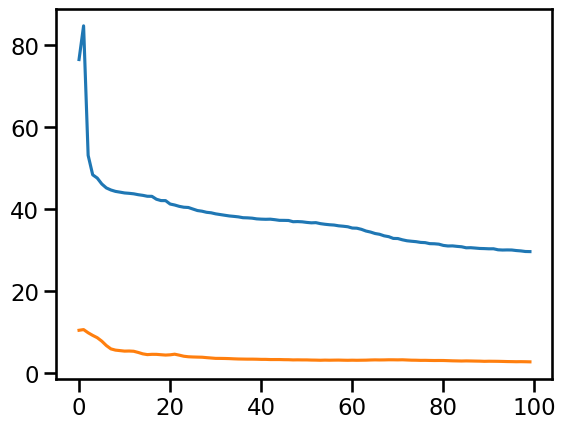

In [12]:
plt.plot(loss_cl_list)
plt.plot(loss_rec_list)

In [13]:
ad_mult = ad_mult_rna.copy()
ad_mult.obsm['emb1'] = (ad_mult_rna.obsm['emb1'] + ad_mult_atac.obsm['emb1']) / 2

ad_mosaic = sc.concat([ad_mult, ad_test_rna, ad_test_atac])
ad_mosaic = utls.get_umap(ad_mosaic, ['emb1'])

/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


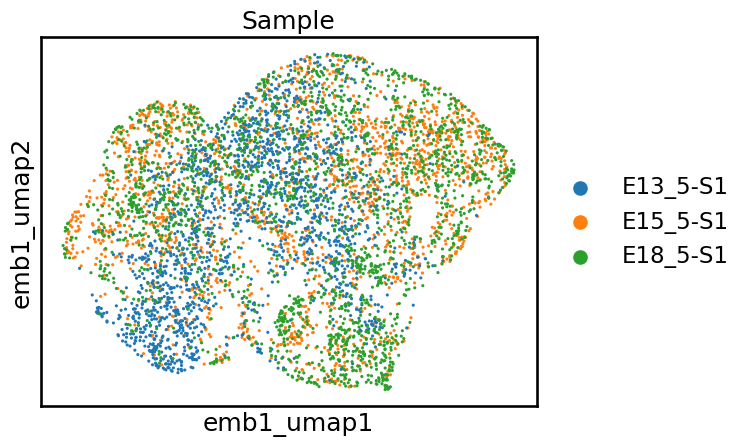

In [14]:
utls.plot_basis(ad_mosaic, 'emb1_umap', ['Sample'])

In [15]:
utls.clustering(ad_mosaic, 12, 'emb1', algo='mclust', key='mclust')
utls.split_adata_ob([ad_mult_rna, ad_test_rna, ad_test_atac], ad_mosaic, ob='obs', key='mclust')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |                                                                      |   0%

/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/rpy2/robjects/numpy2ri.py:252: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


  |======================================================================| 100%


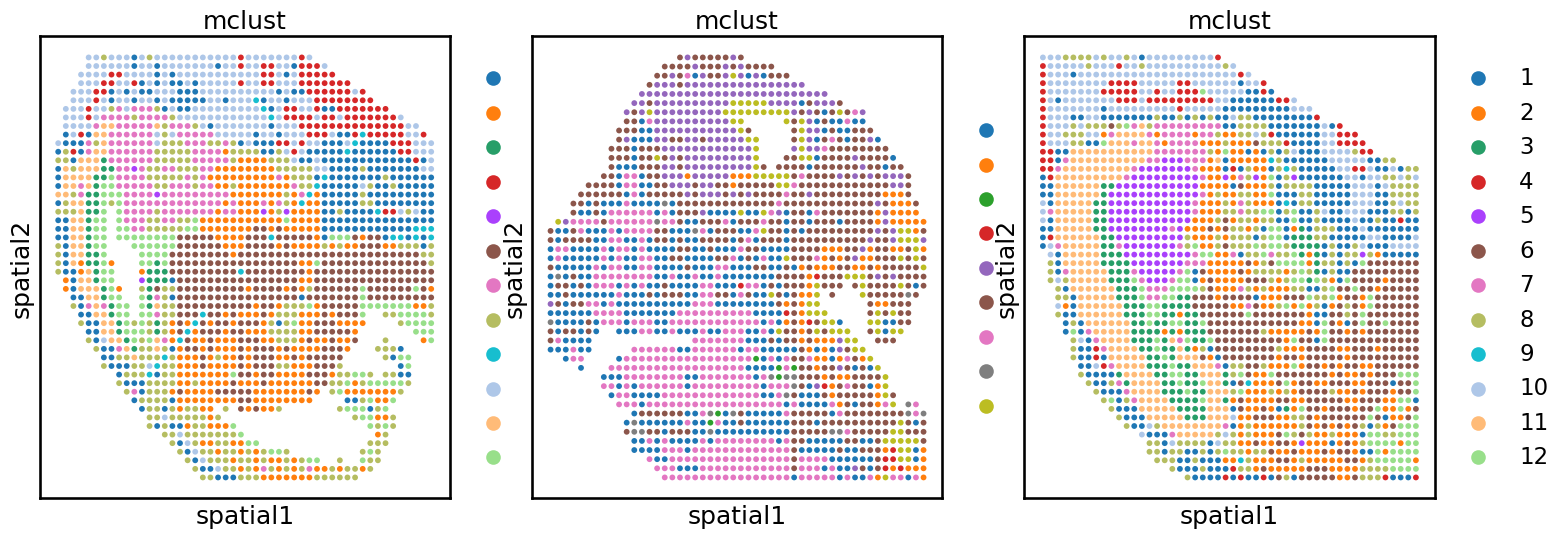

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

utls.plot_basis(ad_mult_rna, 'spatial', ['mclust'], s=70, ax=axes[0], show=False)
utls.plot_basis(ad_test_rna, 'spatial', ['mclust'], s=70, ax=axes[1], show=False)
utls.plot_basis(ad_test_atac, 'spatial', ['mclust'], s=70, ax=axes[2], show=False)

In [17]:
os.makedirs('../../../results/embeddings/SpaMosaic(non-spatial)/Misar-E15-13-18', exist_ok=True)
pd.DataFrame(ad_mosaic.obsm['emb1'], index=ad_mosaic.obs_names).to_csv(f'../../../results/embeddings/SpaMosaic(non-spatial)/Misar-E15-13-18/df_emb.csv')

### Lymph

In [4]:
ds = 'Lymph'

data_dir = '../../../data/processed/Lymph-S1-S2-S3'
ad_mult_rna = sc.read_h5ad(join(data_dir, 'S1/ad_rna.h5ad'))
ad_mult_adt = sc.read_h5ad(join(data_dir, 'S1/ad_adt.h5ad'))
ad_test_rna = sc.read_h5ad(join(data_dir, 'S2/ad_rna.h5ad'))
ad_test_adt = sc.read_h5ad(join(data_dir, 'S3/ad_adt.h5ad'))

input_key = 'dimred_bc'

RNA_preprocess([ad_mult_rna, ad_test_rna], batch_corr=True, n_hvg=10000, batch_key='src', key=input_key)
ADT_preprocess([ad_mult_adt, ad_test_adt], batch_corr=True, batch_key='src', key=input_key)

<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject


Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
Reach convergence after 5 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
Reach convergence after 3 iteration(s).


In [5]:
ad_mult_rna, ad_mult_adt, ad_test_rna, ad_test_adt, loss_cl_list, loss_rec_list = train_stage1(
    ad_mult_rna, ad_mult_adt, 
    ad_test_rna, ad_test_adt, 
    input_key=input_key,
    layer_dims=[128, 64], batch_size=256,
    n_layer=2, n_dec_l=1, out_dim=32, hid_dim=128, lr=0.01, T=0.1, rec_w=1., n_epochs=100,
    emb_key='emb1', seed=1234, 
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
)

100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [00:38<00:00,  2.62it/s]


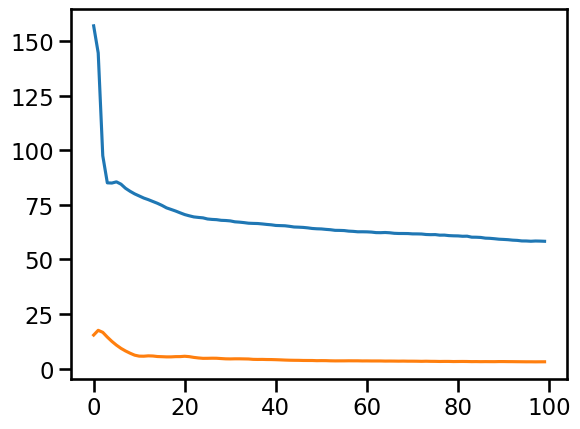

In [6]:
plt.plot(loss_cl_list)
plt.plot(loss_rec_list)

/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


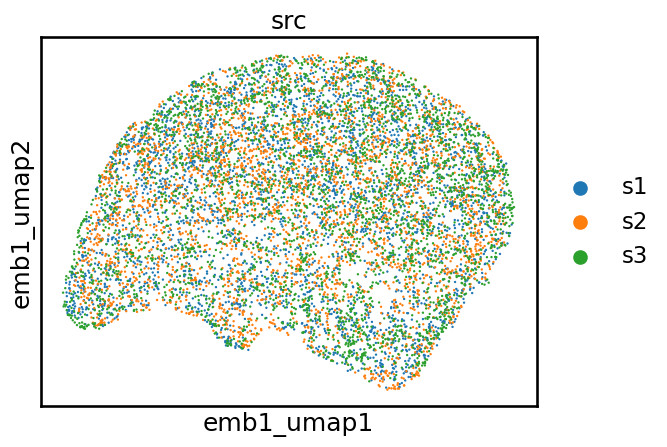

In [7]:
ad_mult = ad_mult_rna.copy()
ad_mult.obsm['emb1'] = (ad_mult_rna.obsm['emb1'] + ad_mult_adt.obsm['emb1']) / 2

ad_mosaic = sc.concat([ad_mult, ad_test_rna, ad_test_adt])
ad_mosaic = utls.get_umap(ad_mosaic, ['emb1'])

utls.plot_basis(ad_mosaic, 'emb1_umap', ['src'])

In [8]:
utls.clustering(ad_mosaic, 8, 'emb1', algo='mclust', key='mclust')
utls.split_adata_ob([ad_mult_rna, ad_test_rna, ad_test_adt], ad_mosaic, ob='obs', key='mclust')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.

/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/rpy2/robjects/numpy2ri.py:252: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


fitting ...
  |======================================================================| 100%


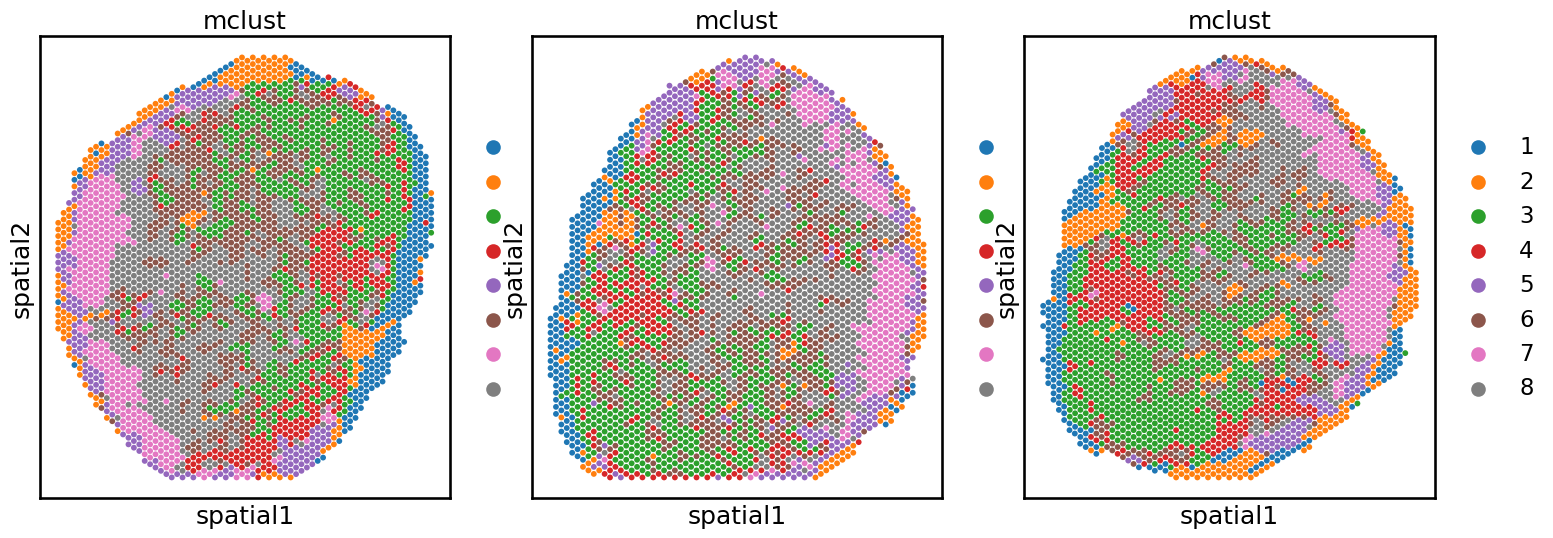

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

utls.plot_basis(ad_mult_rna, 'spatial', ['mclust'], s=70, ax=axes[0], show=False)
utls.plot_basis(ad_test_rna, 'spatial', ['mclust'], s=70, ax=axes[1], show=False)
utls.plot_basis(ad_test_adt, 'spatial', ['mclust'], s=70, ax=axes[2], show=False)

In [10]:
os.makedirs(f'../../../results/embeddings/SpaMosaic(non-spatial)/Lymph-S1-S2-S3', exist_ok=True)
pd.DataFrame(ad_mosaic.obsm['emb1'], index=ad_mosaic.obs_names).to_csv(f'../../../results/embeddings/SpaMosaic(non-spatial)/Lymph-S1-S2-S3/df_emb.csv')

### Misar-Stereo

In [41]:
ds = 'Misar-Stereo'

data_dir = '../../../data/processed/Misar-Stereo'

ad_mis13_rna = sc.read_h5ad(join(data_dir, 'Misar-E13/ad_rna.h5ad'))
ad_mis13_atac = sc.read_h5ad(join(data_dir, 'Misar-E13/ad_atac.h5ad'))

ad_mis15_rna = sc.read_h5ad(join(data_dir, 'Misar-E15/ad_rna.h5ad'))
ad_mis15_atac = sc.read_h5ad(join(data_dir, 'Misar-E15/ad_atac.h5ad'))

ad_mis18_rna = sc.read_h5ad(join(data_dir, 'Misar-E18/ad_rna.h5ad'))
ad_mis18_atac = sc.read_h5ad(join(data_dir, 'Misar-E18/ad_atac.h5ad'))

ad_ste12_rna = sc.read_h5ad(join(data_dir, 'Stereo-E12/ad_rna.h5ad'))
ad_ste14_rna = sc.read_h5ad(join(data_dir, 'Stereo-E14/ad_rna.h5ad')) 
ad_ste16_rna = sc.read_h5ad(join(data_dir, 'Stereo-E16/ad_rna.h5ad')) 

In [30]:
input_key = 'dimred_bc'

R_dir = './cache'
df_cca = pd.read_csv(join(R_dir, 'cca_coordinates.csv'), index_col=0)
for ad in [ad_mis13_rna, ad_mis15_rna, ad_mis18_rna, ad_ste12_rna, ad_ste14_rna, ad_ste16_rna]:
    ad.obsm[input_key] = df_cca.loc[ad.obs_names].values

Epigenome_preprocess([ad_mis13_atac, ad_mis15_atac, ad_mis18_atac], batch_corr=True, n_peak=50000, batch_key='Sample', key=input_key, return_hvf=False)   

Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).
	Completed 10 / 10 iteration(s).


In [31]:
ad_mult_rna = sc.concat([ad_mis13_rna, ad_mis15_rna, ad_mis18_rna])
ad_mult_atac = sc.concat([ad_mis13_atac, ad_mis15_atac, ad_mis18_atac])

ad_test_rna = sc.concat([ad_ste12_rna, ad_ste14_rna, ad_ste16_rna])

In [34]:
ad_mult_rna, ad_mult_atac, ad_test_rna, _, loss_cl_list, loss_rec_list = train_stage1(
    ad_mult_rna, ad_mult_atac, 
    ad_test_rna, None, 
    input_key=input_key,
    layer_dims=[128, 64], batch_size=256,
    n_layer=2, n_dec_l=1, out_dim=32, hid_dim=128, lr=0.01, T=0.1, rec_w=1., n_epochs=100,
    emb_key='emb1', seed=1234, 
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
)

100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [01:16<00:00,  1.31it/s]


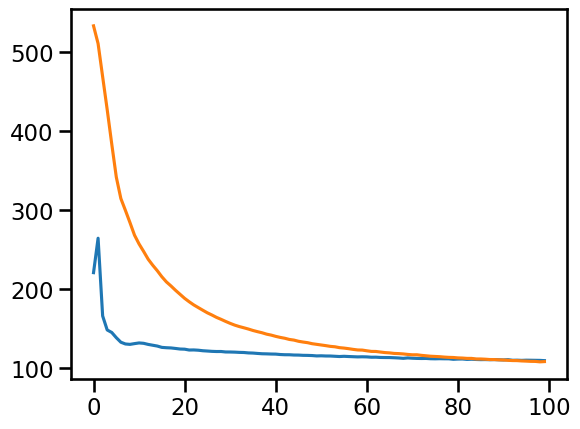

In [35]:
plt.plot(loss_cl_list)
plt.plot(loss_rec_list)

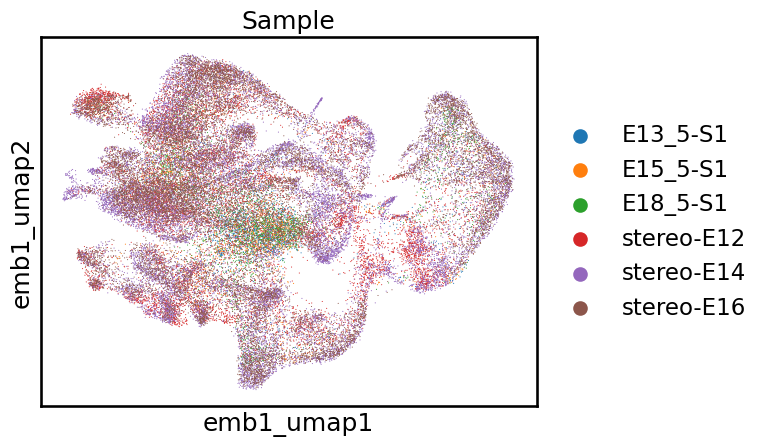

In [36]:
ad_mult = ad_mult_rna.copy()
ad_mult.obsm['emb1'] = (ad_mult_rna.obsm['emb1'] + ad_mult_atac.obsm['emb1']) / 2

ad_mosaic = sc.concat([ad_mult, ad_test_rna])
ad_mosaic = utls.get_umap(ad_mosaic, ['emb1'])

utls.plot_basis(ad_mosaic, 'emb1_umap', ['Sample'])

In [37]:
utls.clustering(ad_mosaic, 15, 'emb1', algo='mclust', key='mclust')
utls.split_adata_ob([ad_mis13_rna, ad_mis15_rna, ad_mis18_rna, ad_ste12_rna, ad_ste14_rna, ad_ste16_rna], ad_mosaic, ob='obs', key='mclust')

/home/yanxh/anaconda3/envs/torch2.0/lib/python3.8/site-packages/rpy2/robjects/numpy2ri.py:252: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


fitting ...
  |======================================================================| 100%


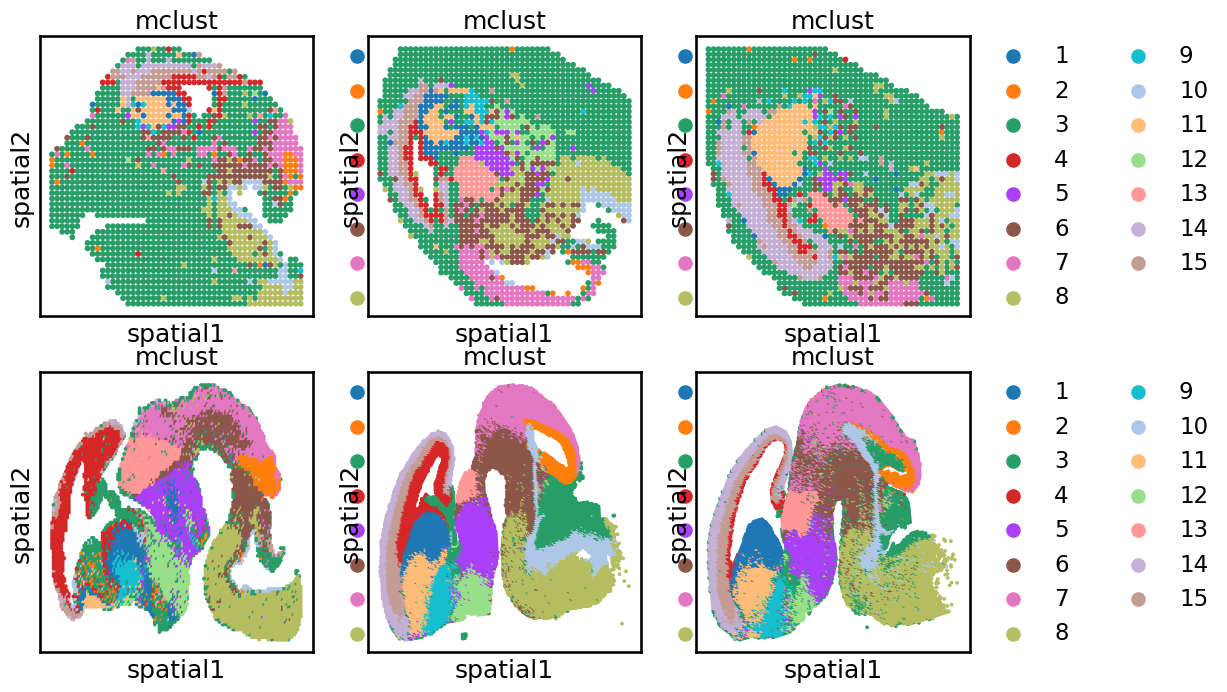

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

utls.plot_basis(ad_mis13_rna, 'spatial', ['mclust'], s=70, ax=axes[0, 0], show=False)
utls.plot_basis(ad_mis15_rna, 'spatial', ['mclust'], s=70, ax=axes[0, 1], show=False)
utls.plot_basis(ad_mis18_rna, 'spatial', ['mclust'], s=70, ax=axes[0, 2], show=False)

utls.plot_basis(ad_ste12_rna, 'spatial', ['mclust'], s=30, ax=axes[1, 0], show=False)
utls.plot_basis(ad_ste14_rna, 'spatial', ['mclust'], s=30, ax=axes[1, 1], show=False)
utls.plot_basis(ad_ste16_rna, 'spatial', ['mclust'], s=30, ax=axes[1, 2], show=False)

plt.show()

In [42]:
os.makedirs(f'../../../results/embeddings/SpaMosaic(non-spatial)/Misar-Stereo', exist_ok=True)
pd.DataFrame(ad_mosaic.obsm['emb1'], index=ad_mosaic.obs_names).to_csv(f'../../../results/embeddings/SpaMosaic(non-spatial)/Misar-Stereo/df_emb.csv')

### Simulation

In [44]:
ds = 'Simulation'

data_dir = '../../../data/processed/Simulations/'
fs = list(sorted(os.listdir(data_dir)))

for fn in fs:
    for seed in [1,2,3]:
        _dir = join(data_dir, fn, str(seed))
        ad_mult_rna = sc.read_h5ad(join(_dir, 'ad_rna1.h5ad'))
        ad_mult_adt = sc.read_h5ad(join(_dir, 'ad_adt1.h5ad'))
        ad_test_rna = sc.read_h5ad(join(_dir, 'ad_rna2.h5ad'))
        ad_test_adt = sc.read_h5ad(join(_dir, 'ad_adt2.h5ad'))
        
        ad_mult_rna.X = ad_mult_rna.layers['counts'].copy()
        ad_mult_adt.X = ad_mult_adt.layers['counts'].copy()
        ad_test_rna.X = ad_test_rna.layers['counts'].copy()
        ad_test_adt.X = ad_test_adt.layers['counts'].copy()

        # 添加 src 标签
        ad_mult_rna.obs['src'] = 's1'
        ad_mult_adt.obs['src'] = 's1'
        ad_test_rna.obs['src'] = 's2'
        ad_test_adt.obs['src'] = 's3'

        # 给 test 的 obs_names 加前缀
        ad_test_rna.obs_names = [f"test-mod1-{i}" for i in range(ad_test_rna.n_obs)]
        ad_test_adt.obs_names = [f"test-mod2-{i}" for i in range(ad_test_adt.n_obs)]

        # concat
        ad_rna = sc.concat([ad_mult_rna, ad_test_rna])
        ad_atac = sc.concat([ad_mult_adt, ad_test_adt])

        # scale + pca + harmony
        sc.pp.scale(ad_rna)
        sc.pp.pca(ad_rna, n_comps=50)
        ad_rna.obsm['X_pca_har'] = harmony(
            ad_rna.obsm['X_pca'],
            ad_rna.obs['src'].to_list(),
            use_gpu=True
        )
        utls.split_adata_ob([ad_mult_rna, ad_test_rna], ad_rna, ob='obsm', key='X_pca_har')

        sc.pp.scale(ad_atac)
        sc.pp.pca(ad_atac, n_comps=50)
        ad_atac.obsm['X_pca_har'] = harmony(
            ad_atac.obsm['X_pca'],
            ad_atac.obs['src'].to_list(),
            use_gpu=True
        )
        utls.split_adata_ob([ad_mult_adt, ad_test_adt], ad_atac, ob='obsm', key='X_pca_har')
        
        ad_mult_rna, ad_mult_adt, ad_test_rna, ad_test_adt, loss_cl_list, loss_rec_list = train_stage1(
            ad_mult_rna, ad_mult_adt, 
            ad_test_rna, ad_test_adt, 
            input_key='X_pca_har',
            layer_dims=[128, 64], batch_size=256,
            n_layer=2, n_dec_l=1, out_dim=32, hid_dim=128, lr=0.01, T=0.1, rec_w=1., n_epochs=100,
            emb_key='emb1', seed=1234, 
            device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
        )

        ad_mult = ad_mult_rna.copy()
        ad_mult.obsm['emb1'] = (ad_mult_rna.obsm['emb1'] + ad_mult_adt.obsm['emb1']) / 2

        ad_mosaic = sc.concat([ad_mult, ad_test_rna, ad_test_adt])
        # ad_mosaic = utls.get_umap(ad_mosaic, use_reps=['merged_emb'])

        os.makedirs(f'../../../results/embeddings/SpaMosaic(non-spatial)/{ds}/{fn}/{seed}', exist_ok=True)
        pd.DataFrame(ad_mosaic.obsm['merged_emb'], index=ad_mosaic.obs_names).to_csv(f'../../../results/embeddings/SpaMosaic(non-spatial)/{ds}/{fn}/{seed}/df_emb.csv')

Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
Reach convergence after 8 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).
Reach convergence after 9 iteration(s).


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.70it/s]


Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
Reach convergence after 7 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
Reach convergence after 8 iteration(s).


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 16.32it/s]


Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
Reach convergence after 7 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
Reach convergence after 7 iteration(s).


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 17.69it/s]


Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
Reach convergence after 4 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).
	Completed 10 / 10 iteration(s).


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 16.84it/s]


Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
Reach convergence after 6 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).
Reach convergence after 9 iteration(s).


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 16.40it/s]
